# Email address: kamal.md.zahid@gmail.com

### DataSet Url: https://github.com/phitronio/Python-for-ML/blob/main/final-employee-ds.csv

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# First, we'll visit the given url, and will collect the url of the raw csv dataset.
raw_dataset_url = "https://raw.githubusercontent.com/phitronio/Python-for-ML/refs/heads/main/final-employee-ds.csv"


# Then we'll read the data from the url of the raw csv dataset and will convert it into a pandas dataframe.
employees_df = pd.read_csv(raw_dataset_url)
employees_df.head()

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
0,101,Employee_1,50,Male,IT,17,86175.0,44,71,2010-01-10,L,2,4,1
1,102,Employee_2,36,Male,Finance,1,47805.0,44,68,2017-11-11,S,4,18,4
2,103,Employee_3,29,Male,Marketing,16,45237.0,44,69,2012-03-08,S,6,13,3
3,104,Employee_4,42,Male,Marketing,12,60056.0,48,76,2012-10-12,M,2,25,4
4,105,Employee_5,40,Female,Finance,19,85543.0,36,97,2014-12-30,XL,8,3,4


### Answer to the Question 1:

In [2]:
# Now we'll load all the values of the 'TrainingHours' column of the 'employees_df' dataframe, into a NumPy array.
trainingHoursColumn = np.array(employees_df['TrainingHours'])

# trainingHoursColumn.dtype
# Currently, the data type is int64.

# Now we'll convert the data type from int64 to float.
trainingHoursColumn = trainingHoursColumn.astype(float)

# trainingHoursColumn.dtype
# Now the data type has been converted to float64.

# Now we'll calculate the mean and standard deviation of the 'TrainingHours' column of the 'employees_df' dataframe.
print(trainingHoursColumn.mean())
print(trainingHoursColumn.std())

24.19
13.842467265628624


### Answer to the Question 2:

In [3]:
# First, we'll find the rows where values in the 'Salary' column are missing.
employees_df[employees_df['Salary'].isnull()]

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
9,110,Employee_10,57,Male,IT,19,NaN,44,86,2021-05-21,M,8,17,2
19,120,Employee_20,54,Female,Finance,3,NaN,47,76,2015-06-24,M,6,14,5
49,150,Employee_50,27,Female,Finance,16,NaN,38,80,2017-09-15,M,5,32,4
89,190,Employee_90,29,Female,Finance,18,NaN,48,79,2014-09-16,M,7,22,2


In [4]:
# Now we'll consider the 'Salary' column of the 'employees_df' dataframe, then will find the median of the respective 'Department's 'Salary' values.
employees_df.groupby('Department')['Salary'].median()

Department
Finance        91991.0
HR             84078.0
IT            104272.5
Management    106801.0
Marketing     110766.5
Name: Salary, dtype: float64

In [5]:
# Now we exactly know which specific value we should write in which cell.


# In this phase, we'll transform each cell of the 'Salary' column of the 'employees_df' dataframe by the respective Department's median. And will store it in a new column named 'salary_column_by_dept_median'.
salary_column_by_dept_median = employees_df.groupby('Department')['Salary'].transform('median')


# Now in the original dataframe, in the 'Salary' column, we'll find the NaN value cells, and will replace the NaN values with the same cell values of the 'salary_column_by_dept_median' column.
# And as the inplace=True is not working in this case, we'll take another approach to write the values in respective cells.
employees_df['Salary'] = employees_df['Salary'].fillna(salary_column_by_dept_median)

In [6]:
# Now we'll check if we have any more missing values in the 'Salary' column.
employees_df[employees_df['Salary'].isnull()]

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating


In [7]:
# Now we'll check the exact rows of the 'Salary' column where we set the values according to the median of the respective 'Department's 'Salary' values.
employees_df.iloc[[9, 19, 49, 89]]

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
9,110,Employee_10,57,Male,IT,19,104272.5,44,86,2021-05-21,M,8,17,2
19,120,Employee_20,54,Female,Finance,3,91991.0,47,76,2015-06-24,M,6,14,5
49,150,Employee_50,27,Female,Finance,16,91991.0,38,80,2017-09-15,M,5,32,4
89,190,Employee_90,29,Female,Finance,18,91991.0,48,79,2014-09-16,M,7,22,2


In [8]:
# NOw we'll calculate and find the total salary sum for the employees with 'ExperienceYears' > 12 and 'ProjectCount' > 5.
# employees_df[(employees_df['ExperienceYears'] > 12) & (employees_df['ProjectCount'] > 5)]
employees_df[(employees_df['ExperienceYears'] > 12) & (employees_df['ProjectCount'] > 5)]['Salary'].sum()

np.float64(1985775.5)

### Answer to the Question 3:

In [9]:
# Now we'll find the employees only where the Department is 'IT' or 'Finance'.
# employees_df[employees_df['Department'].isin(['IT', 'Finance'])]


# And where the Age is between 30 and 45.
# employees_df[(employees_df['Age'] >= 30) & (employees_df['Age'] <= 45)]
# employees_df[employees_df['Age'].between(30, 45)]


# And where the PerformanceScore is > 88
# employees_df[employees_df['PerformanceScore'] > 88].sort_values(by='Salary', ascending=False)


# Now we'll combine all conditions and find the employees only where the Department is 'IT' or 'Finance', and the Age is between 30 and 45, and the PerformanceScore is > 88. And we'll sort the dataframe by Salary in descending order. And finally, we'll show the 'Name', 'Department', 'Salary', 'PerformanceScore' columns.'
(employees_df[
     (employees_df['Department'].isin(['IT', 'Finance']))
     & (employees_df['Age'].between(30, 45))
     & (employees_df['PerformanceScore'] > 88)
     ]
 .sort_values(by='Salary', ascending=False))[['Name', 'Department', 'Salary', 'PerformanceScore']]

,Name,Department,Salary,PerformanceScore
94,Employee_95,IT,140386.0,94
88,Employee_89,Finance,126027.0,92
4,Employee_5,Finance,85543.0,97
32,Employee_33,IT,83919.0,98
55,Employee_56,Finance,49540.0,94


### Answer to the Question 4:

In [10]:
# Now, we'll create anew column 'SalaryPerHour', and will store a value, which is value = Salary ÷ (WorkHoursPerWeek × 4)
employees_df['SalaryPerHour'] = employees_df['Salary'] / (employees_df['WorkHoursPerWeek'] * 4)


# Now we'll sort the dataframe by SalaryPerHour in descending order, and will show the top 5 rows. And we'll show the 'Name' and 'SalaryPerHour' columns only.
employees_df.sort_values(by='SalaryPerHour', ascending=False).head(5)[['Name', 'SalaryPerHour']]

,Name,SalaryPerHour
46,Employee_47,981.278571
27,Employee_28,971.292857
31,Employee_32,967.392857
79,Employee_80,945.335526
80,Employee_81,937.858974


### Answer to the Question 5:

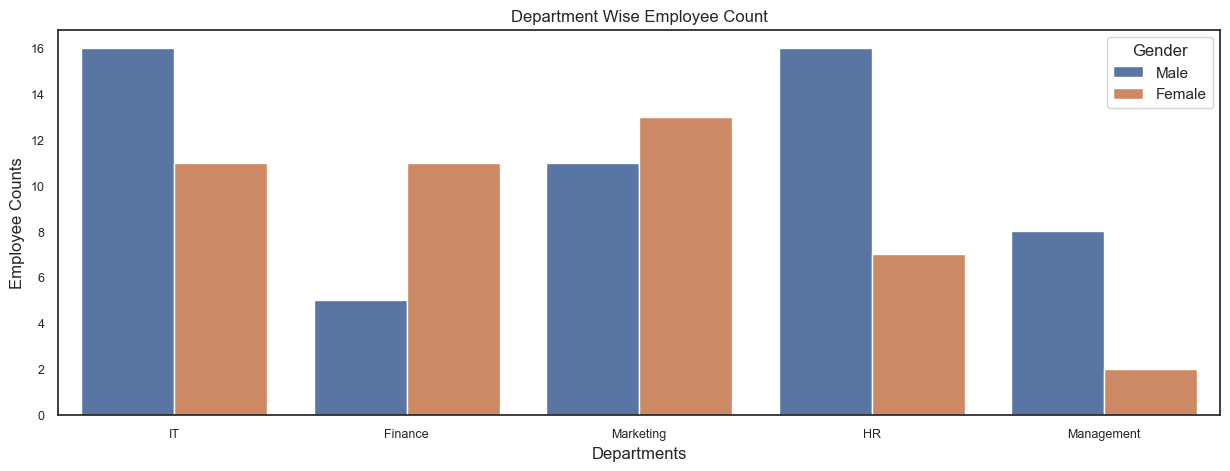

In [145]:
# Now we'll create a Bar chart, using Seaborn, where x-axis will represent the 'Department' column and y-axis will represent the employee count.
# We'll also use hue to differentiate the employees based on their gender.

plt.figure(figsize=(15, 5))
sns.countplot(data=employees_df, x='Department', hue='Gender')

plt.title('Department Wise Employee Count and Gender')
plt.xlabel('Departments')
plt.ylabel('Employee Counts')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.show()

---